### Import Libraries

In [1]:
import pandas as pd
import numpy as np

### Load Cleaned Dataset

In [2]:
data = pd.read_csv("vehicle_maintenance_cleaned.csv")

# Check shape and first few rows
print(data.shape)
data.head()

(50000, 20)


,Vehicle_Model,Mileage,Maintenance_History,Reported_Issues,Vehicle_Age,Fuel_Type,Transmission_Type,Engine_Size,Odometer_Reading,Last_Service_Date,Warranty_Expiry_Date,Owner_Type,Insurance_Premium,Service_History,Accident_History,Fuel_Efficiency,Tire_Condition,Brake_Condition,Battery_Status,Need_Maintenance
0,Truck,58765,Good,0,4,Electric,Automatic,2000,28524,2023-11-23,2025-06-24,Second,20782,6,3,13.622204,New,New,Weak,1
1,Van,60353,Average,1,7,Electric,Automatic,2500,133630,2023-09-21,2025-06-04,Second,23489,7,0,13.625307,New,New,Weak,1
2,Bus,68072,Poor,0,2,Electric,Automatic,1500,34022,2023-06-27,2025-04-27,First,17979,7,0,14.306302,New,Good,Weak,1
3,Bus,60849,Average,4,5,Petrol,Automatic,2500,81636,2023-08-24,2025-11-05,Second,6220,7,3,18.709467,New,Worn Out,New,1
4,Bus,45742,Poor,5,1,Petrol,Manual,2000,97162,2023-05-25,2025-09-14,Third,16446,6,2,16.977482,Good,Good,Weak,1


### Encode Categorical Features

In [3]:
print(data['Last_Service_Date'].min(), data['Last_Service_Date'].max())
print(data['Warranty_Expiry_Date'].min(), data['Warranty_Expiry_Date'].max())

2023-03-30 2024-02-28
2024-04-28 2026-03-29


In [4]:
from sklearn.preprocessing import LabelEncoder

# Copy dataframe to avoid changes
data_ml = data.copy()

# Encode categorical columns
categorical_cols = ['Vehicle_Model', 'Maintenance_History', 'Tire_Condition', 'Brake_Condition',
                    'Battery_Status', 'Fuel_Type', 'Transmission_Type', 'Owner_Type'
                   ]
# Initialize the encoder
le = LabelEncoder()

# Loop through all categorical columns
for col in categorical_cols:
    data_ml[col] = le.fit_transform(data_ml[col])

# Convert date columns to datatime
data_ml['Last_Service_Date'] = pd.to_datetime(data_ml['Last_Service_Date'], errors = 'coerce')
data_ml['Warranty_Expiry_Date'] = pd.to_datetime(data_ml['Warranty_Expiry_Date'], errors = 'coerce')

# Fixed reference date for feature engineering
reference_date = pd.to_datetime('2026-01-28')

# Create new numeric features
data_ml['Last_Service_Days'] = (reference_date - data_ml['Last_Service_Date']).dt.days
data_ml['Warranty_Days_Left'] = (data_ml['Warranty_Expiry_Date'] - reference_date).dt.days

# Drop original date columns (not needed for ML)
data_ml.drop(['Last_Service_Date', 'Warranty_Expiry_Date'], axis = 1, inplace = True)

print(data_ml.head())
print(data_ml.info())

   Vehicle_Model  Mileage  Maintenance_History  Reported_Issues  Vehicle_Age  \
0              4    58765                    1                0            4   
1              5    60353                    0                1            7   
2              0    68072                    2                0            2   
3              0    60849                    0                4            5   
4              0    45742                    2                5            1   

   Fuel_Type  Transmission_Type  Engine_Size  Odometer_Reading  Owner_Type  \
0          1                  0         2000             28524           1   
1          1                  0         2500            133630           1   
2          1                  0         1500             34022           0   
3          2                  0         2500             81636           1   
4          2                  1         2000             97162           2   

   Insurance_Premium  Service_History  Accident_Hi

### Split Data into Features & Target

In [5]:
X = data_ml.drop('Need_Maintenance', axis = 1)
y = data_ml['Need_Maintenance']

### Train-Test Split

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42, stratify = y
)

print(X_train.shape, X_test.shape)

(40000, 19) (10000, 19)


### Identify & Scale Numeric Columns

In [7]:
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

### Logistic Regression Model

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_auc_score

# Initialize model
log_reg = LogisticRegression(max_iter = 2000)

# Train model
log_reg.fit(X_train_scaled, y_train)

# Make predictions
y_pred_lr = log_reg.predict(X_test_scaled)
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

# Evaluate
print('Logistic Regression Accuracy:', accuracy_score(y_test, y_pred_lr))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred_lr))
print('\nClassification Report:\n', classification_report(y_test, y_pred_lr))
print('\nROC-AUC Score:\n', roc_auc_score(y_test, y_prob_lr))

Logistic Regression Accuracy: 0.8845

Confusion Matrix:
 [[1138  762]
 [ 393 7707]]

Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.60      0.66      1900
           1       0.91      0.95      0.93      8100

    accuracy                           0.88     10000
   macro avg       0.83      0.78      0.80     10000
weighted avg       0.88      0.88      0.88     10000


ROC-AUC Score:
 0.9265943469785575


### Random Forest Model

In [9]:
from sklearn.ensemble import RandomForestClassifier

# Initialize model
rf = RandomForestClassifier(n_estimators = 100, random_state = 42, class_weight = 'balanced')

# Train model
rf.fit(X_train, y_train)

# Predict
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

# Evaluate
print('Random Forest Accuracy:', accuracy_score(y_test, y_pred_rf))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred_rf))
print('\nClassification Report:\n', classification_report(y_test, y_pred_rf))
print('\nROC-AUC Score:\n', roc_auc_score(y_test, y_prob_rf))

Random Forest Accuracy: 1.0

Confusion Matrix:
 [[1900    0]
 [   0 8100]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1900
           1       1.00      1.00      1.00      8100

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000


ROC-AUC Score:
 1.0


### Check Feature Importance

In [10]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns, 'Importance': rf.feature_importances_
}).sort_values(by = 'Importance', ascending = False)

feature_importance.head(10)

,Feature,Importance
3,Reported_Issues,0.336556
15,Brake_Condition,0.240607
16,Battery_Status,0.238409
12,Accident_History,0.048626
2,Maintenance_History,0.044813
11,Service_History,0.043254
13,Fuel_Efficiency,0.006287
1,Mileage,0.006283
10,Insurance_Premium,0.006200
8,Odometer_Reading,0.006175


### Remove Leaking Features & Retrain

In [11]:
leakage_features = ['Brake_Condition', 'Battery_Status', 'Maintenance_History', 'Service_History']

X_train_clean = X_train.drop(leakage_features, axis = 1)
X_test_clean = X_test.drop(leakage_features, axis = 1)

rf_clean = RandomForestClassifier(n_estimators = 100, random_state = 42, class_weight = 'balanced')

rf_clean.fit(X_train_clean, y_train)

y_pred_rf_clean = rf_clean.predict(X_test_clean)
y_prob_rf_clean = rf_clean.predict_proba(X_test_clean)[:, 1]

print('Random Forest Accuracy:', accuracy_score(y_test, y_pred_rf_clean))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred_rf_clean))
print('\nClassification Report:\n', classification_report(y_test, y_pred_rf_clean))
print('\nROC-AUC Score:\n', roc_auc_score(y_test, y_prob_rf_clean))

Random Forest Accuracy: 0.8054

Confusion Matrix:
 [[  79 1821]
 [ 125 7975]]

Classification Report:
               precision    recall  f1-score   support

           0       0.39      0.04      0.08      1900
           1       0.81      0.98      0.89      8100

    accuracy                           0.81     10000
   macro avg       0.60      0.51      0.48     10000
weighted avg       0.73      0.81      0.74     10000


ROC-AUC Score:
 0.7865136127355425


### Logistic Regression Threshold Adjustment

In [12]:
threshold = 0.3
y_pred_adj = (y_prob_lr >= threshold).astype(int)

# Evaluate
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred_adj))
print('\nClassification Report:\n', classification_report(y_test, y_pred_adj))
print('\nROC-AUC Score:\n', roc_auc_score(y_test, y_prob_lr))


Confusion Matrix:
 [[ 825 1075]
 [ 131 7969]]

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.43      0.58      1900
           1       0.88      0.98      0.93      8100

    accuracy                           0.88     10000
   macro avg       0.87      0.71      0.75     10000
weighted avg       0.88      0.88      0.86     10000


ROC-AUC Score:
 0.9265943469785575


### ROC Curve For Completeness

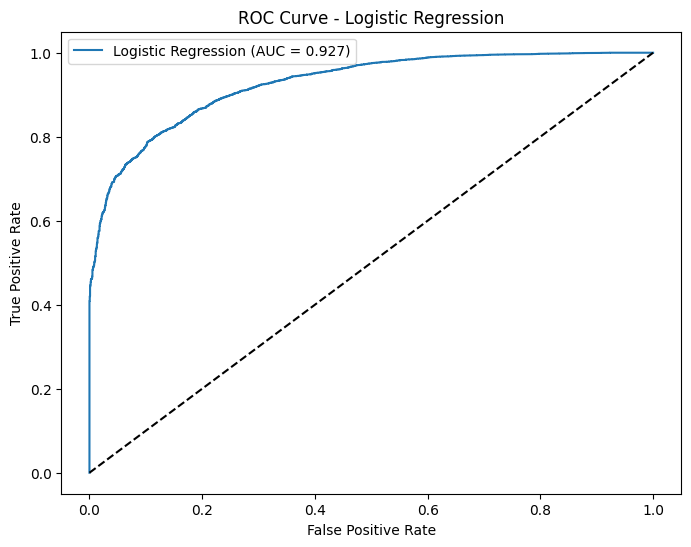

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_lr)

# plot
plt.figure(figsize = (8, 6))
plt.plot(fpr, tpr, label = 'Logistic Regression (AUC = 0.927)')
plt.plot([0,1], [0,1], 'k--') # diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.show()

### Extract Coefficients

In [14]:
# get feature names
feature_names = X_train_scaled.columns

# get coefficients
coefficients =log_reg.coef_[0]

# create a dataframe for easier interpretation
coef_data = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients}).sort_values(by = 'Coefficient', ascending = False)

coef_data

,Feature,Coefficient
3,Reported_Issues,1.918719
15,Brake_Condition,1.455375
16,Battery_Status,1.429966
11,Service_History,0.510070
12,Accident_History,0.381992
2,Maintenance_History,0.284563
4,Vehicle_Age,0.024674
8,Odometer_Reading,0.023636
10,Insurance_Premium,0.014737
1,Mileage,0.012762


### Full Model Prediction

In [15]:
# load dataset
data_full = pd.read_csv('vehicle_maintenance_cleaned.csv')

# Encode categorical columns
categorical_cols = ['Vehicle_Model', 'Maintenance_History', 'Tire_Condition', 'Brake_Condition',
                    'Battery_Status', 'Fuel_Type', 'Transmission_Type', 'Owner_Type'
                   ]
le_dict = {}
for col in categorical_cols:
    le = LabelEncoder()
    data_full[col] = le.fit_transform(data_full[col])
    le_dict[col] = le # save encoder mapping if needed

# Convert date columns to datatime
data_full['Last_Service_Date'] = pd.to_datetime(data_full['Last_Service_Date'], errors = 'coerce')
data_full['Warranty_Expiry_Date'] = pd.to_datetime(data_full['Warranty_Expiry_Date'], errors = 'coerce')

# Fixed reference date for feature engineering
reference_date = pd.to_datetime('2026-01-28')

# Create new numeric features
data_full['Last_Service_Days'] = (reference_date - data_full['Last_Service_Date']).dt.days
data_full['Warranty_Days_Left'] = (data_full['Warranty_Expiry_Date'] - reference_date).dt.days

# Drop original date columns (not needed for ML)
data_full.drop(['Last_Service_Date', 'Warranty_Expiry_Date'], axis = 1, inplace = True)

# separate features and target
X_full = data_full.drop('Need_Maintenance', axis = 1)
y_full = data_full['Need_Maintenance']

# scale numeric columns
numeric_cols = ['Mileage', 'Odometer_Reading', 'Engine_Size', 'Insurance_Premium',
               'Fuel_Efficiency', 'Vehicle_Age', 'Last_Service_Days', 'Warranty_Days_Left']

scaler = StandardScaler()
X_full[numeric_cols] = scaler.fit_transform(X_full[numeric_cols])

# train logistic regression
final_log_reg = LogisticRegression(max_iter = 2000)
final_log_reg.fit(X_full, y_full)

# threshold adjustment
y_prob_full = final_log_reg.predict_proba(X_full)[:, 1]
threshold = 0.3
y_pred_full = (y_prob_full >= threshold).astype(int)

# extract coefficients
coef_data_full = pd.DataFrame({'Feature': X_full.columns,
                               'Coefficient': final_log_reg.coef_[0]
                              }).sort_values(by = 'Coefficient', ascending = False)

coef_data_full

,Feature,Coefficient
15,Brake_Condition,1.780801
16,Battery_Status,1.755277
3,Reported_Issues,1.118092
2,Maintenance_History,0.353437
12,Accident_History,0.348794
11,Service_History,0.180368
4,Vehicle_Age,0.015537
8,Odometer_Reading,0.013324
10,Insurance_Premium,0.012809
6,Transmission_Type,0.009010


In [16]:
data_full.to_csv('C:/Users/user/Desktop/Uswat project/vehicle_maintenance_cleaned_full.csv', index = False)

In [17]:
data_full.head()

,Vehicle_Model,Mileage,Maintenance_History,Reported_Issues,Vehicle_Age,Fuel_Type,Transmission_Type,Engine_Size,Odometer_Reading,Owner_Type,Insurance_Premium,Service_History,Accident_History,Fuel_Efficiency,Tire_Condition,Brake_Condition,Battery_Status,Need_Maintenance,Last_Service_Days,Warranty_Days_Left
0,4,58765,1,0,4,1,0,2000,28524,1,20782,6,3,13.622204,1,1,2,1,797,-218
1,5,60353,0,1,7,1,0,2500,133630,1,23489,7,0,13.625307,1,1,2,1,860,-238
2,0,68072,2,0,2,1,0,1500,34022,0,17979,7,0,14.306302,1,0,2,1,946,-276
3,0,60849,0,4,5,2,0,2500,81636,1,6220,7,3,18.709467,1,2,1,1,888,-84
4,0,45742,2,5,1,2,1,2000,97162,2,16446,6,2,16.977482,0,0,2,1,979,-136


In [18]:
data_readable = data_full.copy()

for col, le in le_dict.items():
    data_readable[col] = le.inverse_transform(data_full[col])

data_readable.to_csv('C:/Users/user/Desktop/Uswat project/vehicle_maintenance_readable_full.csv', index = False)

In [19]:
data_readable.head()

,Vehicle_Model,Mileage,Maintenance_History,Reported_Issues,Vehicle_Age,Fuel_Type,Transmission_Type,Engine_Size,Odometer_Reading,Owner_Type,Insurance_Premium,Service_History,Accident_History,Fuel_Efficiency,Tire_Condition,Brake_Condition,Battery_Status,Need_Maintenance,Last_Service_Days,Warranty_Days_Left
0,Truck,58765,Good,0,4,Electric,Automatic,2000,28524,Second,20782,6,3,13.622204,New,New,Weak,1,797,-218
1,Van,60353,Average,1,7,Electric,Automatic,2500,133630,Second,23489,7,0,13.625307,New,New,Weak,1,860,-238
2,Bus,68072,Poor,0,2,Electric,Automatic,1500,34022,First,17979,7,0,14.306302,New,Good,Weak,1,946,-276
3,Bus,60849,Average,4,5,Petrol,Automatic,2500,81636,Second,6220,7,3,18.709467,New,Worn Out,New,1,888,-84
4,Bus,45742,Poor,5,1,Petrol,Manual,2000,97162,Third,16446,6,2,16.977482,Good,Good,Weak,1,979,-136
